# GRUPPUPPGIFT - DEEP LEARNING - GRUPP5

## 1. Data förtåelse & preprocessing


#### Importer bibliotek


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

#### Ladda in Fashion MNIST drikt från keras

In [2]:
# Ladda datasetet från Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Visa grundläggande information om datasetet
print("====Grundläggande information om datasetet====")
print(f"Träningsbilder: {x_train.shape} (bilder, höjd, bredd)")
print(f"Träningsetiketter: {y_train.shape}")
print(f"Testbilder: {x_test.shape}")
print(f"Testetiketter: {y_test.shape}")
print(f"Antal klasser: {len(np.unique(y_train))}")
print("Pixelvärdesintervall:", x_train.min(), "-", x_train.max())

====Grundläggande information om datasetet====
Träningsbilder: (60000, 28, 28) (bilder, höjd, bredd)
Träningsetiketter: (60000,)
Testbilder: (10000, 28, 28)
Testetiketter: (10000,)
Antal klasser: 10
Pixelvärdesintervall: 0 - 255


#### Undersök klasser och balans


==== Klassfördelning i träningssetet:====
0: T-shirt/top     - 6000 bilder
1: Trouser         - 6000 bilder
2: Pullover        - 6000 bilder
3: Dress           - 6000 bilder
4: Coat            - 6000 bilder
5: Sandal          - 6000 bilder
6: Shirt           - 6000 bilder
7: Sneaker         - 6000 bilder
8: Bag             - 6000 bilder
9: Ankle boot      - 6000 bilder


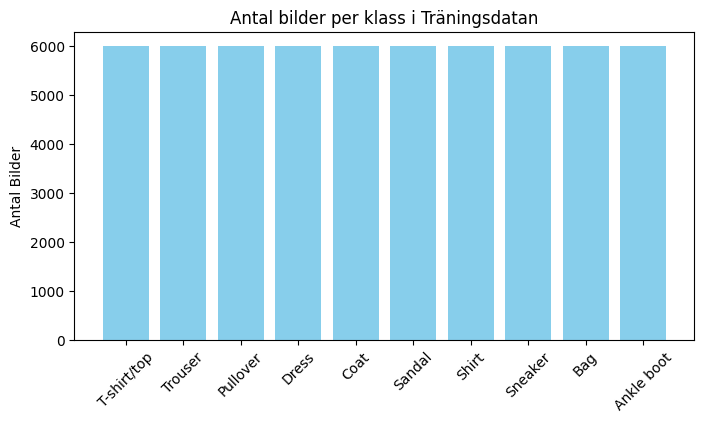

In [3]:
# Klassnamn ( enligt Fashion MNIST namnsättning)
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
    ]

# Undersök klassbalans - räkna antal bilder per klass i träningssetet
unique, counts = np.unique(y_train, return_counts=True)

print("\n==== Klassfördelning i träningssetet:====")
for i, (name, cnt) in enumerate(zip(class_names, counts)):
    print(f"{i}: {name:15} - {cnt} bilder")

# Visualisera några exempelbilder från varje klass
plt.figure(figsize=(8, 4))
plt.bar(class_names, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title("Antal bilder per klass i Träningsdatan")
plt.ylabel("Antal Bilder")
plt.show()

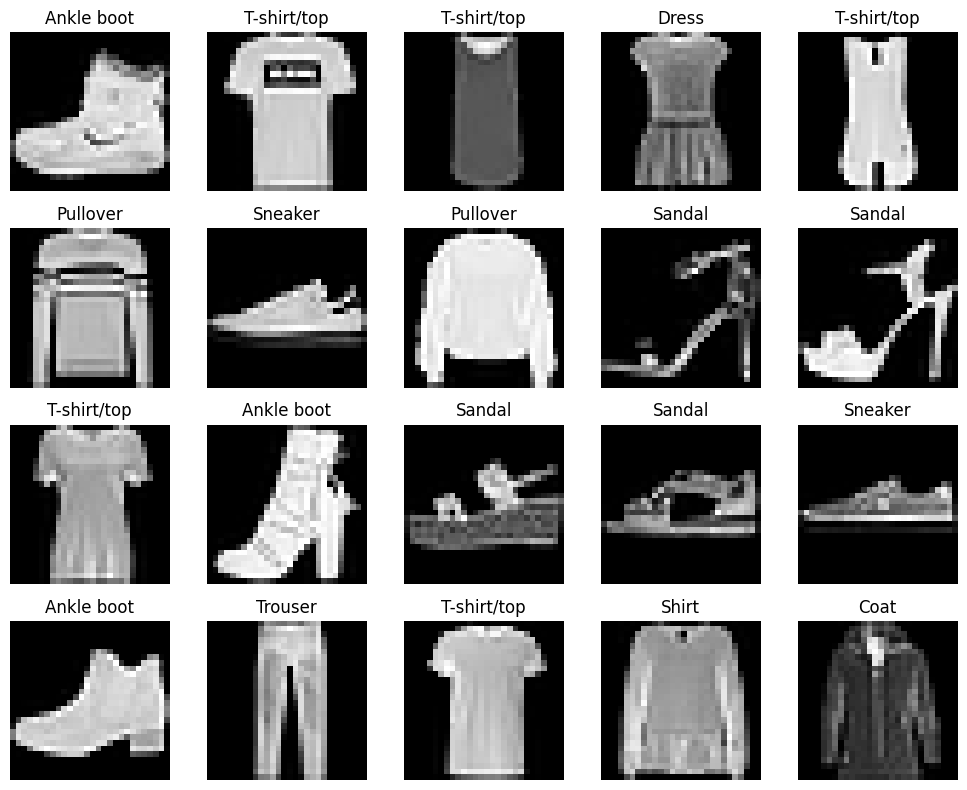

In [4]:
# Visa exempelbilder från varje klass
plt.figure(figsize=(10,8))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

#### Normalisera pixelvärdena till intervallet [0, 1]

In [5]:
# Normalisera pixelvärdena till intervallet [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"\nEfter normalisering - pixelvärden mellan {x_train.min():.2f} och {x_train.max():.2f}")



Efter normalisering - pixelvärden mellan 0.00 och 1.00


### Anpassa input shape för CNN
CNN-lager i Keras kräver en kanaldimension - även för gråskalebilder.

In [6]:
# Lägg till en dimension för kanaler (gråskala) så att datan blir (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print(f"Ny shape för träningsdata: {x_train.shape} (bilder, höjd, bredd, kanaler)")
print(f"Ny shape för testdata: {x_test.shape}")

Ny shape för träningsdata: (60000, 28, 28, 1) (bilder, höjd, bredd, kanaler)
Ny shape för testdata: (10000, 28, 28, 1)


## Sammanfattning för del1:
Sammanfattning av data förståelse och & preprocessing.
- Dataset: Fashion MNIST
- 60 000 träningsbilder, 10 000 testbilder
- Bildstorlek: 28x20 pixlar, gråskala
- Efter normalisering - pixelvärden mellan 0.00 och 1.00
- Input shape redo för CNN: (28, 28, 1)
- Inga saknade värden eller konstigheter
- Data är nu klar för att användas i modell

c:\Users\Mryun\OneDrive\PythonProjects\DL-grupp5-augmentation\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8271 - loss: 0.4788 - val_accuracy: 0.8683 - val_loss: 0.3689
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8841 - loss: 0.3159 - val_accuracy: 0.8924 - val_loss: 0.2950
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9013 - loss: 0.2670 - val_accuracy: 0.8888 - val_loss: 0.2973
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9117 - loss: 0.2357 - val_accuracy: 0.9009 - val_loss: 0.2687
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9220 - loss: 0.2100 - val_accuracy: 0.9090 - val_loss: 0.2514
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9312 - loss: 0.1855 - val_accuracy: 0.9121 - val_loss: 0.2469
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9381 - loss: 0.1632 - val_accuracy: 0.9122 - val_loss: 0.2494
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9444 - loss: 0.1474 -

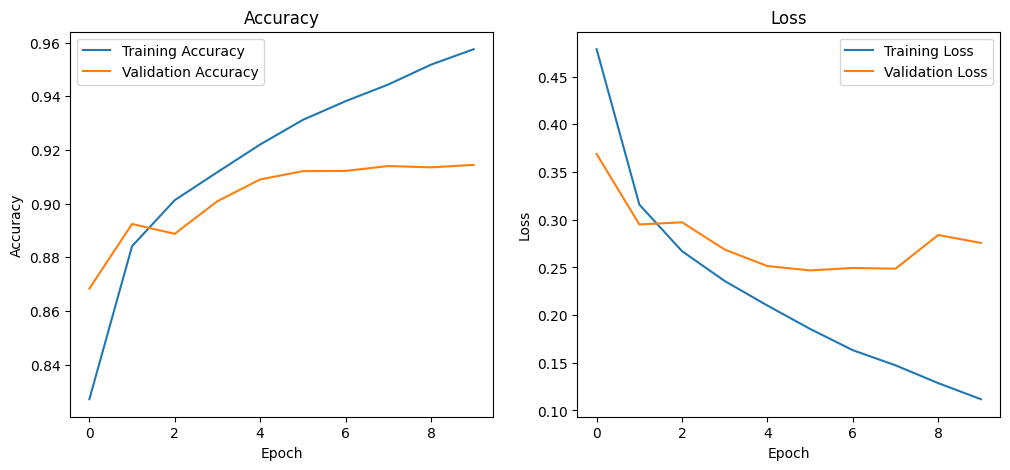

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9110 - loss: 0.2858
Test accuracy: 0.9110
Test loss: 0.2858


In [7]:
# Baseline CNN-modell utan data augmentation

baseline_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = baseline_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

# Visualisera accuracy och loss

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Utvärdera baseline-modellen på testdata

test_loss, test_accuracy = baseline_model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

## 3. Fokusområde: Data Augmentation

**Ansvarig: Yunus**

I den här delen testar vi hur olika former av data augmentation påverkar modellen.

Data augmentation betyder att vi skapar små, realistiska variationer av träningsbilderna under träningen.  
Syftet är inte att skapa nya riktiga bilder, utan att hjälpa modellen att generalisera bättre och minska risken för overfitting.

Vi jämför varje experiment med baseline-modellen utan augmentation.

In [8]:
# Kontrollera att datan har rätt form innan augmentation
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

# Sätt seed för att resultaten ska bli mer jämförbara
tf.random.set_seed(42)
np.random.seed(42)

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


### Visa exempel på augmentation

Innan vi tränar modellerna visar vi hur en bild förändras av olika augmentation-lager.
Det gör det lättare att förstå vad modellen får se under träningen.

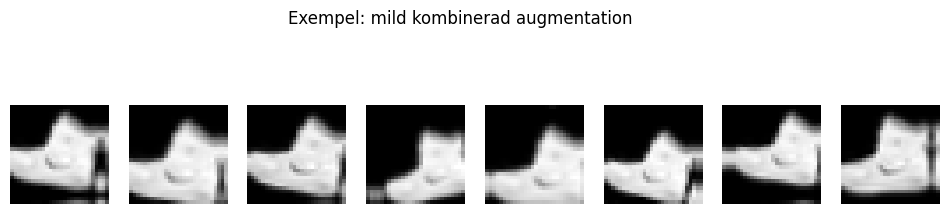

In [9]:
def show_augmented_examples(augmentation_layer, title, image_index=0, n_examples=8):
    image = x_train[image_index:image_index+1]

    plt.figure(figsize=(12, 3))
    for i in range(n_examples):
        augmented_image = augmentation_layer(image, training=True)

        plt.subplot(1, n_examples, i + 1)
        plt.imshow(augmented_image[0].numpy().squeeze(), cmap='gray')
        plt.axis('off')

    plt.suptitle(title)
    plt.show()


# Exempel på mild kombinerad augmentation
example_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10),
])

show_augmented_examples(example_augmentation, "Exempel: mild kombinerad augmentation")

### Funktion för att skapa samma CNN-modell

För att jämförelsen ska bli rättvis använder vi samma CNN-arkitektur i alla experiment.  
Det enda vi ändrar mellan experimenten är augmentation-delen.

In [10]:
def create_cnn_model(augmentation_layer=None):
    model = keras.Sequential()

    # Input-lager
    model.add(layers.Input(shape=(28, 28, 1)))

    # Augmentation används bara under träning.
    # Vid validation/test kör Keras automatiskt utan augmentation.
    if augmentation_layer is not None:
        model.add(augmentation_layer)

    # Samma CNN-struktur som baseline
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

### Experimentfunktion

Den här funktionen tränar en modell, utvärderar den och sparar resultaten i en tabell.  
Det gör att vi inte tappar bort vad vi testade.

In [11]:
experiment_results = []
experiment_histories = {}

def run_experiment(name, augmentation_layer=None, epochs=10, batch_size=32):
    print(f"\n===== Experiment: {name} =====")

    model = create_cnn_model(augmentation_layer)

    history_exp = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        validation_split=0.2,
        batch_size=batch_size,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    final_train_acc = history_exp.history['accuracy'][-1]
    final_val_acc = history_exp.history['val_accuracy'][-1]
    final_train_loss = history_exp.history['loss'][-1]
    final_val_loss = history_exp.history['val_loss'][-1]

    experiment_results.append({
        "experiment": name,
        "train_accuracy": final_train_acc,
        "val_accuracy": final_val_acc,
        "test_accuracy": test_accuracy,
        "train_loss": final_train_loss,
        "val_loss": final_val_loss,
        "test_loss": test_loss,
        "comment": ""
    })

    experiment_histories[name] = history_exp

    print(f"Train accuracy: {final_train_acc:.4f}")
    print(f"Validation accuracy: {final_val_acc:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")

    return model, history_exp

### Experiment 1: Endast rotation

Här testar vi om små rotationer hjälper modellen.  
För Fashion MNIST kan mild rotation vara rimligt, men för stark rotation kan vissa klädesplagg bli onaturliga.

In [12]:
rotation_aug = keras.Sequential([
    layers.RandomRotation(0.05)
])

rotation_model, rotation_history = run_experiment(
    name="Rotation 5%",
    augmentation_layer=rotation_aug
)


===== Experiment: Rotation 5% =====
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7955 - loss: 0.5480 - val_accuracy: 0.8492 - val_loss: 0.4114
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8602 - loss: 0.3798 - val_accuracy: 0.8739 - val_loss: 0.3458
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8765 - loss: 0.3312 - val_accuracy: 0.8892 - val_loss: 0.3096
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8878 - loss: 0.3009 - val_accuracy: 0.8947 - val_loss: 0.2980
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8954 - loss: 0.2797 - val_accuracy: 0.8942 - val_loss: 0.2931
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9030 - loss: 0.2609 - val_accuracy: 0.8989 - val_loss: 0.2783
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9080 - loss: 0.2463 - val_accuracy: 0.8982 - val_loss: 0.2892
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step

### Experiment 2: Endast zoom

Här testar vi om modellen blir bättre när plaggen ibland visas lite större eller mindre.  
Det kan hjälpa om objektet inte alltid är exakt centrerat eller lika stort.

In [13]:
zoom_aug = keras.Sequential([
    layers.RandomZoom(0.10)
])

zoom_model, zoom_history = run_experiment(
    name="Zoom 10%",
    augmentation_layer=zoom_aug
)


===== Experiment: Zoom 10% =====
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8099 - loss: 0.5115 - val_accuracy: 0.8703 - val_loss: 0.3649
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8723 - loss: 0.3489 - val_accuracy: 0.8835 - val_loss: 0.3258
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8889 - loss: 0.3021 - val_accuracy: 0.8981 - val_loss: 0.2885
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8996 - loss: 0.2693 - val_accuracy: 0.9026 - val_loss: 0.2789
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9094 - loss: 0.2446 - val_accuracy: 0.9054 - val_loss: 0.2708
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9163 - loss: 0.2239 - val_accuracy: 0.9028 - val_loss: 0.2755
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9231 - loss: 0.2057 - val_accuracy: 0.9093 - val_loss: 0.2716
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - 

### Experiment 3: Endast translation/shift

Här flyttas bilden lite i höjd- och sidled.  
Det kan hjälpa modellen att inte bli för beroende av exakt position i bilden.

In [14]:
shift_aug = keras.Sequential([
    layers.RandomTranslation(0.10, 0.10)
])

shift_model, shift_history = run_experiment(
    name="Shift 10%",
    augmentation_layer=shift_aug
)


===== Experiment: Shift 10% =====
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7659 - loss: 0.6329 - val_accuracy: 0.8397 - val_loss: 0.4332
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8308 - loss: 0.4487 - val_accuracy: 0.8599 - val_loss: 0.3691
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8524 - loss: 0.3943 - val_accuracy: 0.8791 - val_loss: 0.3324
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8668 - loss: 0.3597 - val_accuracy: 0.8907 - val_loss: 0.2994
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8744 - loss: 0.3357 - val_accuracy: 0.8906 - val_loss: 0.2991
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8794 - loss: 0.3193 - val_accuracy: 0.8927 - val_loss: 0.2901
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8852 - loss: 0.3063 - val_accuracy: 0.8873 - val_loss: 0.2987
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step -

### Experiment 4: Mild kombinerad augmentation

Här kombinerar vi rotation, zoom och shift i mild nivå.  
Detta är ofta mer realistiskt än att bara testa en sak, men för mycket augmentation kan också störa modellen.

In [15]:
mild_combined_aug = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10)
])

mild_combined_model, mild_combined_history = run_experiment(
    name="Mild kombinerad augmentation",
    augmentation_layer=mild_combined_aug
)


===== Experiment: Mild kombinerad augmentation =====
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7286 - loss: 0.7193 - val_accuracy: 0.8049 - val_loss: 0.5418
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8006 - loss: 0.5284 - val_accuracy: 0.8253 - val_loss: 0.4892
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8238 - loss: 0.4688 - val_accuracy: 0.8489 - val_loss: 0.4135
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8370 - loss: 0.4298 - val_accuracy: 0.8576 - val_loss: 0.3968
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8449 - loss: 0.4092 - val_accuracy: 0.8592 - val_loss: 0.3921
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8540 - loss: 0.3861 - val_accuracy: 0.8546 - val_loss: 0.3911
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8591 - loss: 0.3715 - val_accuracy: 0.8513 - val_loss: 0.4087
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━

### Experiment 5: Starkare kombinerad augmentation

Här testar vi en starkare variant för att se om mer augmentation hjälper eller skadar.  
På små 28x28-bilder kan stark augmentation ibland göra viktig information svårare att tolka.

In [16]:
strong_combined_aug = keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.20),
    layers.RandomTranslation(0.20, 0.20)
])

strong_combined_model, strong_combined_history = run_experiment(
    name="Stark kombinerad augmentation",
    augmentation_layer=strong_combined_aug
)


===== Experiment: Stark kombinerad augmentation =====
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5698 - loss: 1.1777 - val_accuracy: 0.7160 - val_loss: 0.7704
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6861 - loss: 0.8536 - val_accuracy: 0.7350 - val_loss: 0.7310
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7196 - loss: 0.7630 - val_accuracy: 0.7707 - val_loss: 0.6344
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7412 - loss: 0.7069 - val_accuracy: 0.7819 - val_loss: 0.5828
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7534 - loss: 0.6678 - val_accuracy: 0.7452 - val_loss: 0.6659
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7645 - loss: 0.6422 - val_accuracy: 0.7823 - val_loss: 0.5879
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7742 - loss: 0.6149 - val_accuracy: 0.7921 - val_loss: 0.5738
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━

### Jämförelsetabell

Här samlar vi resultaten från alla augmentation-experiment.  
Fyll gärna i korta kommentarer efter varje körning: hjälpte, skadade eller gav ungefär samma resultat?

In [17]:
results_df = pd.DataFrame(experiment_results)

# Sortera efter validation accuracy eftersom det visar hur modellen fungerar på osedd validation-data
results_df = results_df.sort_values(by="val_accuracy", ascending=False)

display(results_df)

,experiment,train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss,comment
1,Zoom 10%,0.937750,0.911167,0.9069,0.166088,0.274686,0.303199,
2,Shift 10%,0.895104,0.903250,0.8982,0.277273,0.269488,0.289458,
0,Rotation 5%,0.919833,0.898250,0.8893,0.214420,0.287544,0.315359,
3,Mild kombinerad augmentation,0.872417,0.873417,0.8657,0.339444,0.357479,0.379661,
4,Stark kombinerad augmentation,0.788833,0.798083,0.7947,0.570411,0.542774,0.557492,


### Visualisera jämförelse mellan experiment

Den här grafen gör det lättare att se vilka experiment som gav bäst validation/test accuracy.

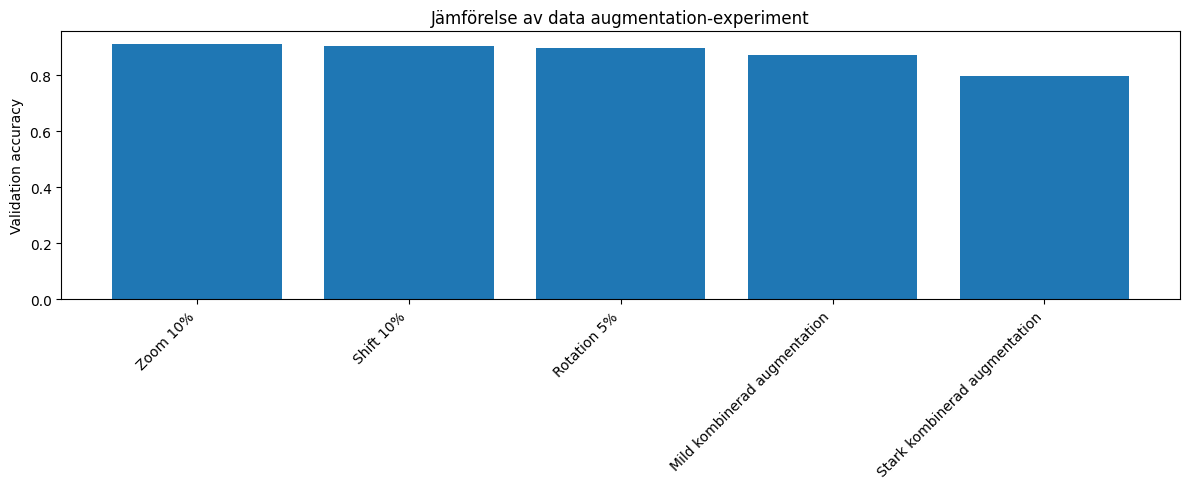

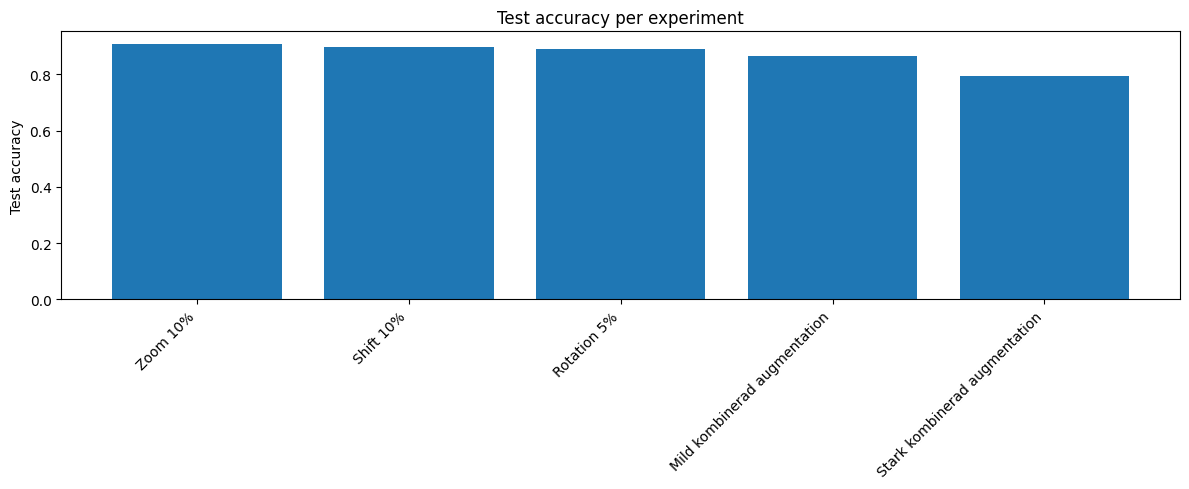

In [18]:
plt.figure(figsize=(12, 5))
plt.bar(results_df["experiment"], results_df["val_accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation accuracy")
plt.title("Jämförelse av data augmentation-experiment")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(results_df["experiment"], results_df["test_accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test accuracy")
plt.title("Test accuracy per experiment")
plt.tight_layout()
plt.show()

### Träningskurvor för alla experiment

Här kan vi se om augmentation minskar overfitting.  
Ett vanligt tecken på overfitting är att training accuracy fortsätter uppåt medan validation accuracy stannar eller sjunker.

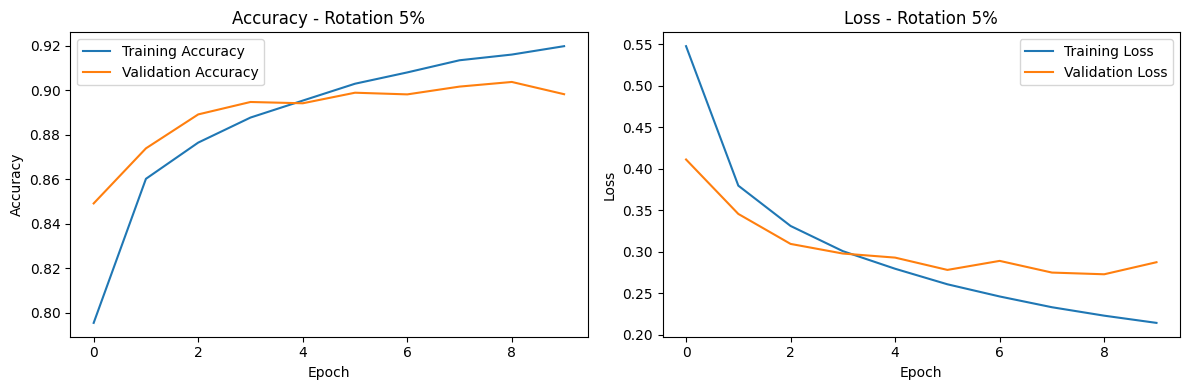

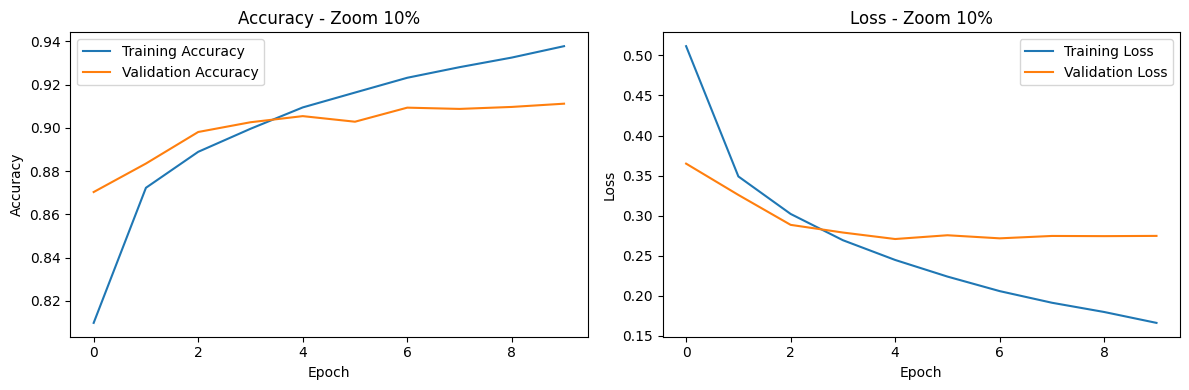

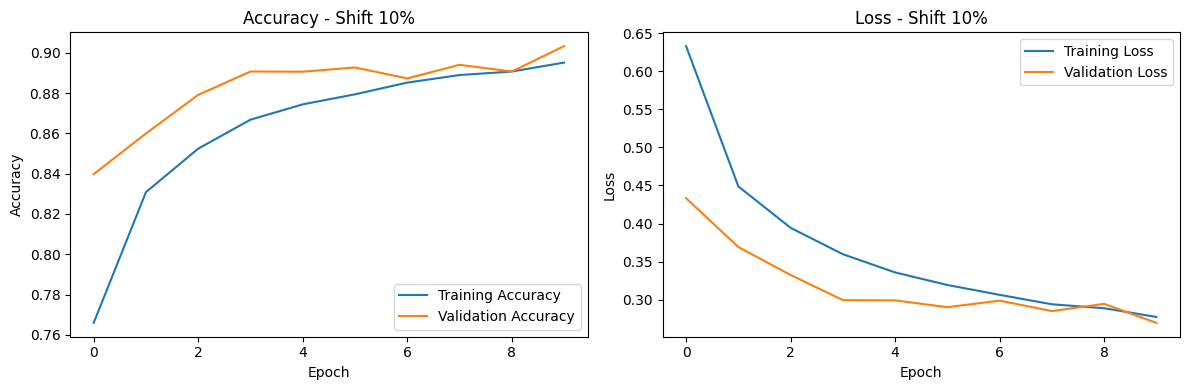

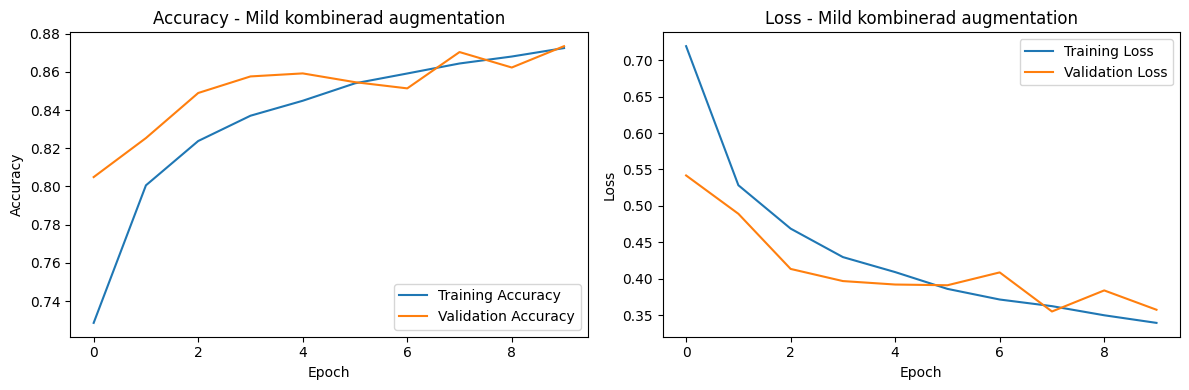

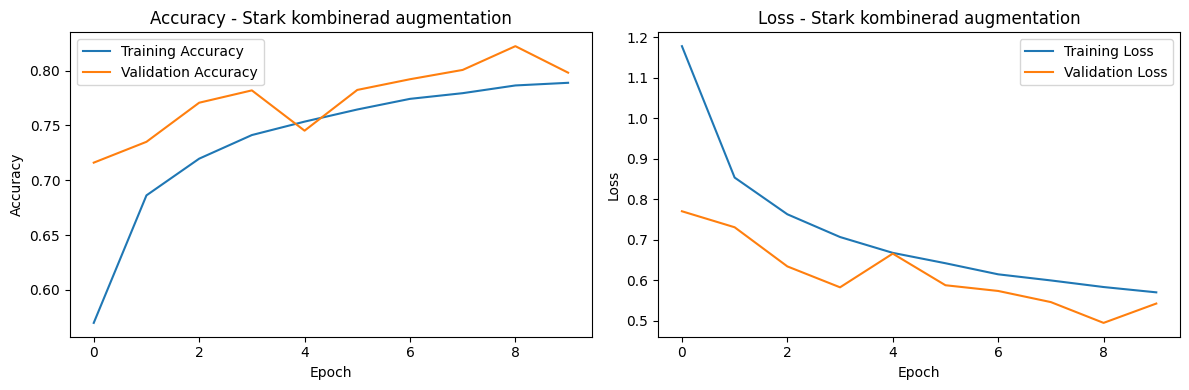

In [19]:
for name, hist in experiment_histories.items():
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist.history['accuracy'], label='Training Accuracy')
    plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy - {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist.history['loss'], label='Training Loss')
    plt.plot(hist.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss - {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

### Analysmall: Data Augmentation

Skriv analysen efter att ni har kört experimenten.

**Vad vi testade:**  
Vi testade rotation, zoom, shift samt mild och stark kombinerad augmentation.

**Varför vi testade detta:**  
Fashion MNIST-bilder kan variera lite i position, storlek och vinkel. Augmentation kan därför göra modellen mindre känslig för små variationer och minska overfitting.

**Vad vi såg i resultaten:**  
Fyll i efter körning:
- Bästa experiment:
- Sämsta experiment:
- Skillnad mot baseline:
- Påverkades training accuracy?
- Påverkades validation accuracy?
- Såg vi mindre eller mer overfitting?

**Tolkning:**  
Om augmentation förbättrar validation/test accuracy kan det betyda att modellen generaliserar bättre.  
Om stark augmentation försämrar resultatet kan det bero på att bilderna blir för förändrade jämfört med riktiga Fashion MNIST-bilder.

**Begränsning:**  
Fashion MNIST består av små 28x28 gråskalebilder. För stark augmentation kan därför ta bort detaljer som modellen behöver för att skilja exempelvis Shirt, Pullover och Coat.